# Cancer Risk Prediction Model

This notebook trains a Decision Tree Classifier to predict cancer risk based on genomic data (genotypes) and phenotypic information.

## Dataset Information
- **Source**: Simulated using QMSim (Sargolzaei & Schenkel, 2009)
- **Total Animals**: 12,010 in pedigree
- **Phenotyped Animals**: 10,000
- **Genotyped Animals**: 2,024 (with phenotypes)
- **SNP Markers**: ~45,000 SNPs
- **QTL**: 500 QTL explaining all genetic variance
- **Heritability**: 0.4 (additive genetic variance: 0.4, residual variance: 0.6)
- **Average LD**: 0.18

## 1. Import Libraries and Setup

In [2]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -----------------

In [3]:
import sys
print(sys.executable)

d:\VitalScanAI\.venv\Scripts\python.exe


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# File Paths
BASE_DIR = "./dataset/Data_ssGBLUP"
PEDIGREE_PATH = os.path.join(BASE_DIR, "pedigree.txt")
PHENOTYPES_PATH = os.path.join(BASE_DIR, "phenotypes.txt")
GENOTYPES_PATH = os.path.join(BASE_DIR, "genotypes.txt")
GEN_MAP_PATH = os.path.join(BASE_DIR, "gen_map.txt")
MODEL_EXPORT_PATH = "cancer_risk_model.joblib"

print("✓ Libraries imported successfully")
print(f"✓ Working directory: {os.getcwd()}")

✓ Libraries imported successfully
✓ Working directory: d:\VitalScanAI\backend\Models\Cancer_risk


## 2. Load Data

In [5]:
# Load all datasets
try:
    print("Loading data...")
    
    # Load pedigree data
    pedigree_df = pd.read_csv(PEDIGREE_PATH, sep=' ', header=None, names=['ID', 'Sire', 'Dam'])
    print(f"✓ Pedigree loaded: {pedigree_df.shape[0]} animals")
    
    # Load phenotype data
    phenotypes_df = pd.read_csv(PHENOTYPES_PATH, sep=' ', header=None, 
                                names=['ID', 'Sex', 'Phenotype', 'TrueBreedingValue', 'Generation'])
    print(f"✓ Phenotypes loaded: {phenotypes_df.shape[0]} records")
    
    # Load genetic map
    gen_map_df = pd.read_csv(GEN_MAP_PATH, sep=' ', header=None, 
                            names=['SNP_Order', 'Chromosome', 'Position_bp'])
    print(f"✓ Genetic map loaded: {gen_map_df.shape[0]} SNPs")
    
    # Load genotypes (this may take a moment due to file size)
    print("Loading genotypes (this may take a moment)...")
    genotypes_df = pd.read_csv(GENOTYPES_PATH, sep=' ', header=None)
    genotypes_df['ID'] = genotypes_df[0]
    genotypes_df['genotype_string'] = genotypes_df[5]
    print(f"✓ Genotypes loaded: {genotypes_df.shape[0]} animals")
    
    print("\n✓ All data loaded successfully!")
    
except FileNotFoundError as e:
    print(f"Error: Data files not found. {e}")
    print("Please ensure paths are correct.")
except Exception as e:
    print(f"An error occurred: {e}")

Loading data...
✓ Pedigree loaded: 10000 animals
✓ Phenotypes loaded: 10000 records
✓ Genetic map loaded: 45001 SNPs
Loading genotypes (this may take a moment)...
✓ Genotypes loaded: 2024 animals

✓ All data loaded successfully!


## 3. Exploratory Data Analysis (EDA)

### 3.1 Pedigree Analysis

In [6]:
print("=" * 60)
print("PEDIGREE ANALYSIS")
print("=" * 60)

print("\nPedigree Data Sample:")
print(pedigree_df.head(10))

print("\nPedigree Statistics:")
print(f"Total animals in pedigree: {len(pedigree_df)}")
print(f"Animals with unknown sire (0): {(pedigree_df['Sire'] == 0).sum()}")
print(f"Animals with unknown dam (0): {(pedigree_df['Dam'] == 0).sum()}")
print(f"Founder animals (both parents unknown): {((pedigree_df['Sire'] == 0) & (pedigree_df['Dam'] == 0)).sum()}")

# Unique parents
unique_sires = pedigree_df[pedigree_df['Sire'] != 0]['Sire'].nunique()
unique_dams = pedigree_df[pedigree_df['Dam'] != 0]['Dam'].nunique()
print(f"\nUnique sires: {unique_sires}")
print(f"Unique dams: {unique_dams}")

print("\nBasic Statistics:")
print(pedigree_df.describe())

PEDIGREE ANALYSIS

Pedigree Data Sample:
         ID      Sire       Dam
0  UGA42011  UGA41101  UGA34199
1  UGA42012  UGA41101  UGA38407
2  UGA42013  UGA41101  UGA39798
3  UGA42014  UGA41101  UGA37367
4  UGA42015  UGA41101  UGA40507
5  UGA42016  UGA41101  UGA34449
6  UGA42017  UGA41101  UGA37465
7  UGA42018  UGA41101  UGA40205
8  UGA42019  UGA41101  UGA37513
9  UGA42020  UGA41101  UGA34836

Pedigree Statistics:
Total animals in pedigree: 10000
Animals with unknown sire (0): 0
Animals with unknown dam (0): 0
Founder animals (both parents unknown): 0

Unique sires: 30
Unique dams: 3600

Basic Statistics:
              ID      Sire       Dam
count      10000     10000     10000
unique     10000        30      3600
top     UGA42011  UGA41101  UGA40507
freq           1       400         5


### 3.2 Phenotype Analysis

In [7]:
print("=" * 60)
print("PHENOTYPE ANALYSIS")
print("=" * 60)

print("\nPhenotype Data Sample:")
print(phenotypes_df.head(10))

print("\nPhenotype Statistics:")
print(phenotypes_df.describe())

print("\nSex Distribution:")
print(phenotypes_df['Sex'].value_counts())

print("\nGeneration Distribution:")
print(phenotypes_df['Generation'].value_counts().sort_index())

# Check for missing values
print("\nMissing Values:")
print(phenotypes_df.isnull().sum())

PHENOTYPE ANALYSIS

Phenotype Data Sample:
         ID  Sex  Phenotype  TrueBreedingValue  Generation
0  UGA42011    1    2.28041           1.345096           1
1  UGA42012    2    1.70218           0.585191           1
2  UGA42013    1    2.99941           1.421061           1
3  UGA42014    2    2.42271           0.915579           1
4  UGA42015    1    2.26410           0.037312           1
5  UGA42016    1    3.20266           0.433457           1
6  UGA42017    1    3.03824           1.100832           1
7  UGA42018    1    3.44542           0.809979           1
8  UGA42019    2    2.21919           1.251130           1
9  UGA42020    1    2.53575           0.476598           1

Phenotype Statistics:
                Sex     Phenotype  TrueBreedingValue    Generation
count  10000.000000  10000.000000       10000.000000  10000.000000
mean       1.496600      2.029261           0.539695      3.000000
std        0.500013      1.085880           0.557135      1.414284
min        1.0000

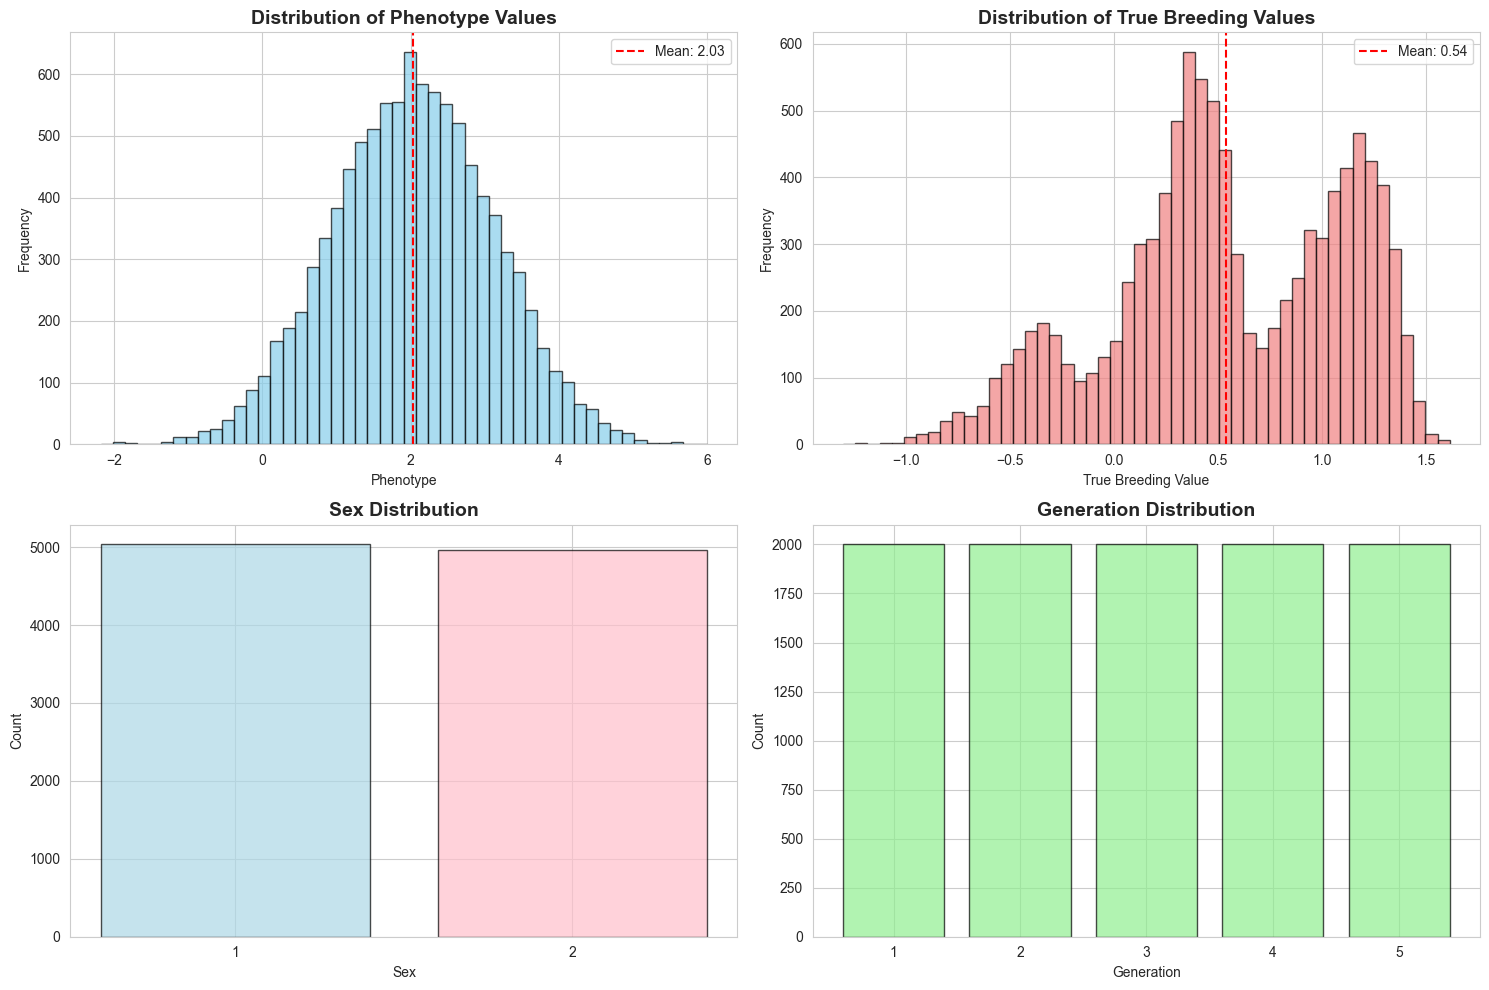

✓ Phenotype visualizations complete


In [8]:
# Visualize phenotype distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Phenotype distribution
axes[0, 0].hist(phenotypes_df['Phenotype'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Phenotype Values', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Phenotype')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(phenotypes_df['Phenotype'].mean(), color='red', linestyle='--', label=f'Mean: {phenotypes_df["Phenotype"].mean():.2f}')
axes[0, 0].legend()

# True Breeding Value distribution
axes[0, 1].hist(phenotypes_df['TrueBreedingValue'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of True Breeding Values', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('True Breeding Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(phenotypes_df['TrueBreedingValue'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {phenotypes_df["TrueBreedingValue"].mean():.2f}')
axes[0, 1].legend()

# Sex distribution
sex_counts = phenotypes_df['Sex'].value_counts()
axes[1, 0].bar(sex_counts.index, sex_counts.values, color=['lightblue', 'pink'], edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Sex Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xticks(sex_counts.index)

# Generation distribution
gen_counts = phenotypes_df['Generation'].value_counts().sort_index()
axes[1, 1].bar(gen_counts.index, gen_counts.values, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Generation Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Generation')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("✓ Phenotype visualizations complete")

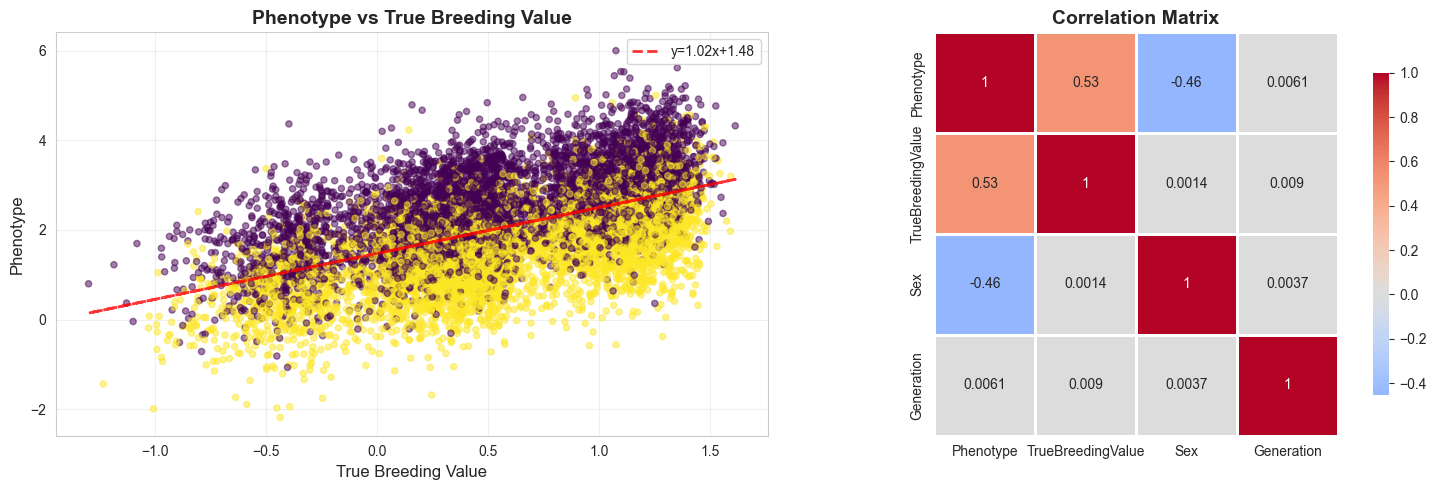


Correlation between Phenotype and True Breeding Value: 0.5256


In [9]:
# Correlation analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot: Phenotype vs True Breeding Value
axes[0].scatter(phenotypes_df['TrueBreedingValue'], phenotypes_df['Phenotype'], 
               alpha=0.5, c=phenotypes_df['Sex'], cmap='viridis', s=20)
axes[0].set_xlabel('True Breeding Value', fontsize=12)
axes[0].set_ylabel('Phenotype', fontsize=12)
axes[0].set_title('Phenotype vs True Breeding Value', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(phenotypes_df['TrueBreedingValue'], phenotypes_df['Phenotype'], 1)
p = np.poly1d(z)
axes[0].plot(phenotypes_df['TrueBreedingValue'], p(phenotypes_df['TrueBreedingValue']), 
            "r--", alpha=0.8, linewidth=2, label=f'y={z[0]:.2f}x+{z[1]:.2f}')
axes[0].legend()

# Correlation coefficient
correlation = phenotypes_df[['Phenotype', 'TrueBreedingValue', 'Sex', 'Generation']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=axes[1], 
           square=True, linewidths=1, cbar_kws={"shrink": 0.8})
axes[1].set_title('Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCorrelation between Phenotype and True Breeding Value: {phenotypes_df['Phenotype'].corr(phenotypes_df['TrueBreedingValue']):.4f}")

### 3.3 Genetic Map Analysis

In [10]:
print("=" * 60)
print("GENETIC MAP ANALYSIS")
print("=" * 60)

print("\nGenetic Map Sample:")
print(gen_map_df.head(10))

print("\nGenetic Map Statistics:")
print(gen_map_df.describe())

print("\nChromosome Information:")
print(f"Number of chromosomes: {gen_map_df['Chromosome'].nunique()}")
print(f"Total SNPs: {len(gen_map_df)}")

# SNPs per chromosome
snps_per_chr = gen_map_df['Chromosome'].value_counts().sort_index()
print("\nSNPs per chromosome:")
print(snps_per_chr)

GENETIC MAP ANALYSIS

Genetic Map Sample:
  SNP_Order Chromosome Position_bp
0    SNP_ID        CHR         POS
1     snp_1          1           0
2     snp_2          1       44260
3     snp_3          1       88520
4     snp_4          1      132780
5     snp_5          1      221300
6     snp_6          1      265560
7     snp_7          1      309820
8     snp_8          1      354080
9     snp_9          1      398340

Genetic Map Statistics:
       SNP_Order Chromosome Position_bp
count      45001      45001       45001
unique     45001         30       43376
top       SNP_ID          1           0
freq           1       3037          28

Chromosome Information:
Number of chromosomes: 30
Total SNPs: 45001

SNPs per chromosome:
Chromosome
1      3037
10     1985
11     1994
12     1429
13     1538
14     1412
15     1431
16     1331
17     1318
18     1156
19     1229
2      2387
20     1331
21     1218
22     1143
23      945
24     1136
25      779
26      886
27      784
28    

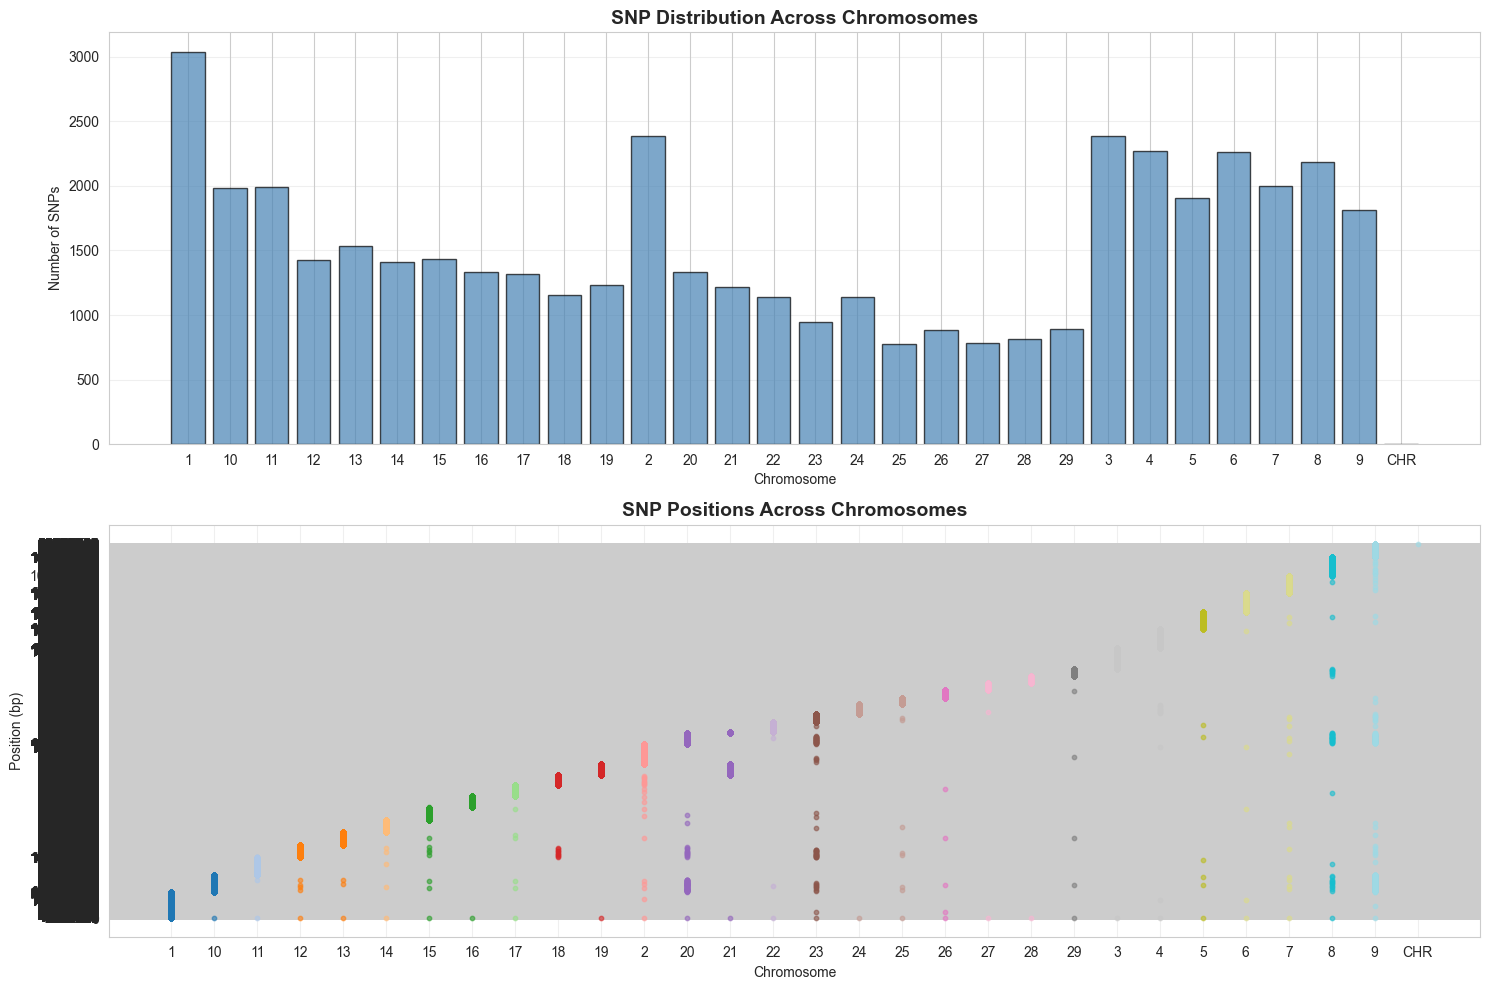

✓ Genetic map visualizations complete


In [11]:
# Visualize SNP distribution across chromosomes
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# SNPs per chromosome bar plot
snps_per_chr = gen_map_df['Chromosome'].value_counts().sort_index()
axes[0].bar(snps_per_chr.index, snps_per_chr.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('SNP Distribution Across Chromosomes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Chromosome')
axes[0].set_ylabel('Number of SNPs')
axes[0].grid(True, alpha=0.3, axis='y')

# SNP positions across genome
colors = plt.cm.tab20(np.linspace(0, 1, gen_map_df['Chromosome'].nunique()))
for i, chr_num in enumerate(sorted(gen_map_df['Chromosome'].unique())):
    chr_data = gen_map_df[gen_map_df['Chromosome'] == chr_num]
    axes[1].scatter([chr_num] * len(chr_data), chr_data['Position_bp'], 
                   alpha=0.6, s=10, color=colors[i], label=f'Chr {chr_num}')

axes[1].set_title('SNP Positions Across Chromosomes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Chromosome')
axes[1].set_ylabel('Position (bp)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Genetic map visualizations complete")

### 3.4 Genotype Analysis

In [12]:
print("=" * 60)
print("GENOTYPE ANALYSIS")
print("=" * 60)

print("\nGenotype Data Sample:")
print(genotypes_df[['ID', 'genotype_string']].head())

print(f"\nTotal genotyped animals: {len(genotypes_df)}")
print(f"Genotype string length (SNPs per animal): {len(genotypes_df['genotype_string'].iloc[0])}")

# Parse first few genotypes to analyze
print("\nParsing sample genotypes for analysis...")
sample_size = min(100, len(genotypes_df))
sample_genotypes = genotypes_df['genotype_string'].head(sample_size).apply(lambda x: np.array(list(x), dtype=int))
sample_matrix = np.vstack(sample_genotypes.values)

print(f"Sample genotype matrix shape: {sample_matrix.shape}")
print(f"\nGenotype encoding (0, 1, 2 representing allele copies):")
print(f"  0: Homozygous reference")
print(f"  1: Heterozygous")
print(f"  2: Homozygous alternative")

# Allele frequency in sample
unique, counts = np.unique(sample_matrix, return_counts=True)
print("\nAllele distribution in sample:")
for allele, count in zip(unique, counts):
    percentage = (count / sample_matrix.size) * 100
    print(f"  Allele {allele}: {count:,} ({percentage:.2f}%)")

GENOTYPE ANALYSIS

Genotype Data Sample:
         ID                                    genotype_string
0  UGA42014  2100212121111121110010011112110200121022001212...
1  UGA42019  2010112021121120101111120121000110121112100212...
2  UGA42029  1011102011211110100001121121100101111022001211...
3  UGA42039  1000201012210220101011120011010201111021110112...
4  UGA42047  2000202022220220000000020022000200220022000222...

Total genotyped animals: 2024
Genotype string length (SNPs per animal): 45000

Parsing sample genotypes for analysis...
Sample genotype matrix shape: (100, 45000)

Genotype encoding (0, 1, 2 representing allele copies):
  0: Homozygous reference
  1: Heterozygous
  2: Homozygous alternative

Allele distribution in sample:
  Allele 0: 1,249,531 (27.77%)
  Allele 1: 2,027,327 (45.05%)
  Allele 2: 1,223,142 (27.18%)


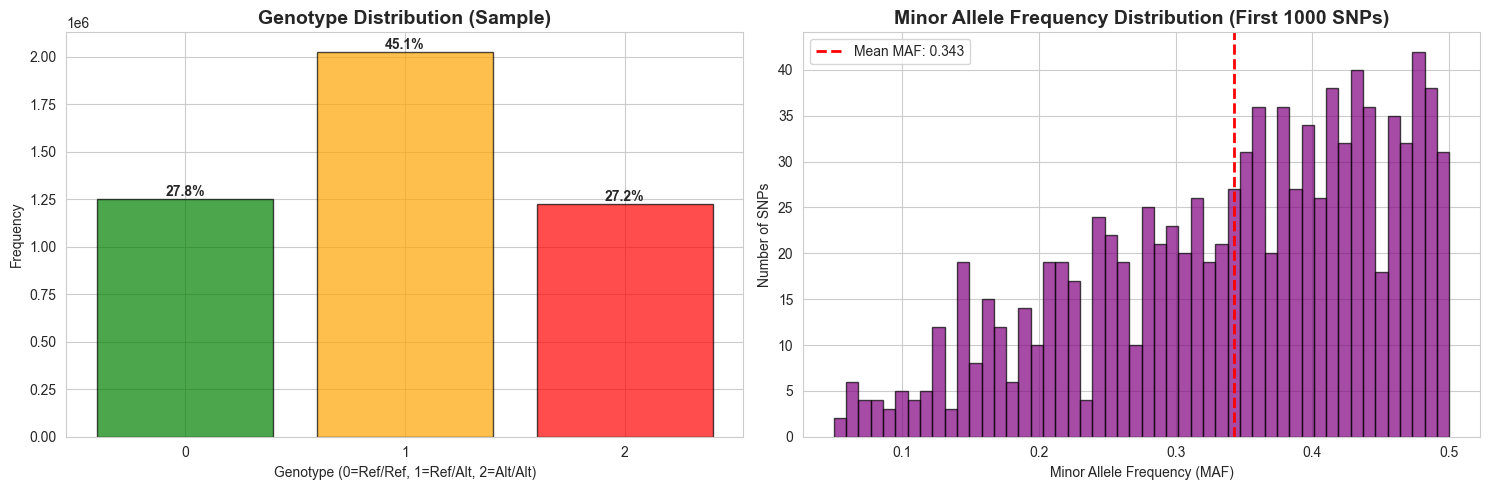


Mean MAF: 0.3426
Median MAF: 0.3650


In [13]:
# Visualize genotype distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Allele frequency distribution
unique, counts = np.unique(sample_matrix, return_counts=True)
axes[0].bar(unique, counts, color=['green', 'orange', 'red'], edgecolor='black', alpha=0.7)
axes[0].set_title('Genotype Distribution (Sample)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Genotype (0=Ref/Ref, 1=Ref/Alt, 2=Alt/Alt)')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks([0, 1, 2])
for i, (allele, count) in enumerate(zip(unique, counts)):
    percentage = (count / sample_matrix.size) * 100
    axes[0].text(allele, count, f'{percentage:.1f}%', ha='center', va='bottom', fontweight='bold')

# Minor allele frequency (MAF) across SNPs
maf_list = []
for snp_idx in range(min(1000, sample_matrix.shape[1])):
    allele_count = sample_matrix[:, snp_idx].sum()
    total_alleles = sample_matrix.shape[0] * 2
    freq = allele_count / total_alleles
    maf = min(freq, 1 - freq)
    maf_list.append(maf)

axes[1].hist(maf_list, bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1].set_title('Minor Allele Frequency Distribution (First 1000 SNPs)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Minor Allele Frequency (MAF)')
axes[1].set_ylabel('Number of SNPs')
axes[1].axvline(np.mean(maf_list), color='red', linestyle='--', linewidth=2, label=f'Mean MAF: {np.mean(maf_list):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMean MAF: {np.mean(maf_list):.4f}")
print(f"Median MAF: {np.median(maf_list):.4f}")

### 3.5 Data Integration Analysis

In [14]:
print("=" * 60)
print("DATA INTEGRATION ANALYSIS")
print("=" * 60)

# Merge datasets
merged_pheno_geno = pd.merge(phenotypes_df, genotypes_df[['ID']], on='ID', how='inner')
merged_all = pd.merge(merged_pheno_geno, pedigree_df, on='ID', how='left')

print(f"\nAnimals with phenotypes: {len(phenotypes_df)}")
print(f"Animals with genotypes: {len(genotypes_df)}")
print(f"Animals with both phenotypes and genotypes: {len(merged_pheno_geno)}")
print(f"Animals in pedigree: {len(pedigree_df)}")

# Venn diagram representation
print("\nData Overlap:")
print(f"  Only phenotypes: {len(phenotypes_df) - len(merged_pheno_geno)}")
print(f"  Both phenotypes and genotypes: {len(merged_pheno_geno)}")
print(f"  Coverage: {(len(merged_pheno_geno) / len(phenotypes_df)) * 100:.2f}% of phenotyped animals are genotyped")

print("\nMerged Dataset Sample:")
print(merged_all.head(10))

DATA INTEGRATION ANALYSIS

Animals with phenotypes: 10000
Animals with genotypes: 2024
Animals with both phenotypes and genotypes: 2024
Animals in pedigree: 10000

Data Overlap:
  Only phenotypes: 7976
  Both phenotypes and genotypes: 2024
  Coverage: 20.24% of phenotyped animals are genotyped

Merged Dataset Sample:
         ID  Sex  Phenotype  TrueBreedingValue  Generation      Sire       Dam
0  UGA42014    2   2.422710           0.915579           1  UGA41101  UGA37367
1  UGA42019    2   2.219190           1.251130           1  UGA41101  UGA37513
2  UGA42029    2   1.745070          -0.001219           1  UGA41101  UGA32495
3  UGA42039    2   2.525450           1.356651           1  UGA41101  UGA41663
4  UGA42047    2   3.462580           0.528261           1  UGA41101  UGA36964
5  UGA42051    2   1.811400           1.120467           1  UGA41101  UGA35424
6  UGA42052    2   0.273868           0.275960           1  UGA41101  UGA34420
7  UGA42056    2   4.546110           1.390367   

## 4. Feature Engineering and Data Preparation

In [15]:
# Parse genotypes into numerical matrix
def parse_genotypes(row):
    """Convert string of '0', '1', '2' into a list of integers"""
    return np.array(list(row), dtype=int)

print("Parsing genotype strings... this may take a moment.")
X_genotypes = np.stack(genotypes_df['genotype_string'].apply(parse_genotypes).values)
print(f"✓ Genotype matrix shape: {X_genotypes.shape}")
print(f"  {X_genotypes.shape[0]} animals × {X_genotypes.shape[1]} SNPs")

Parsing genotype strings... this may take a moment.
✓ Genotype matrix shape: (2024, 45000)
  2024 animals × 45000 SNPs


Risk Class Distribution:
RiskClass
Low       3334
Medium    3333
High      3333
Name: count, dtype: int64


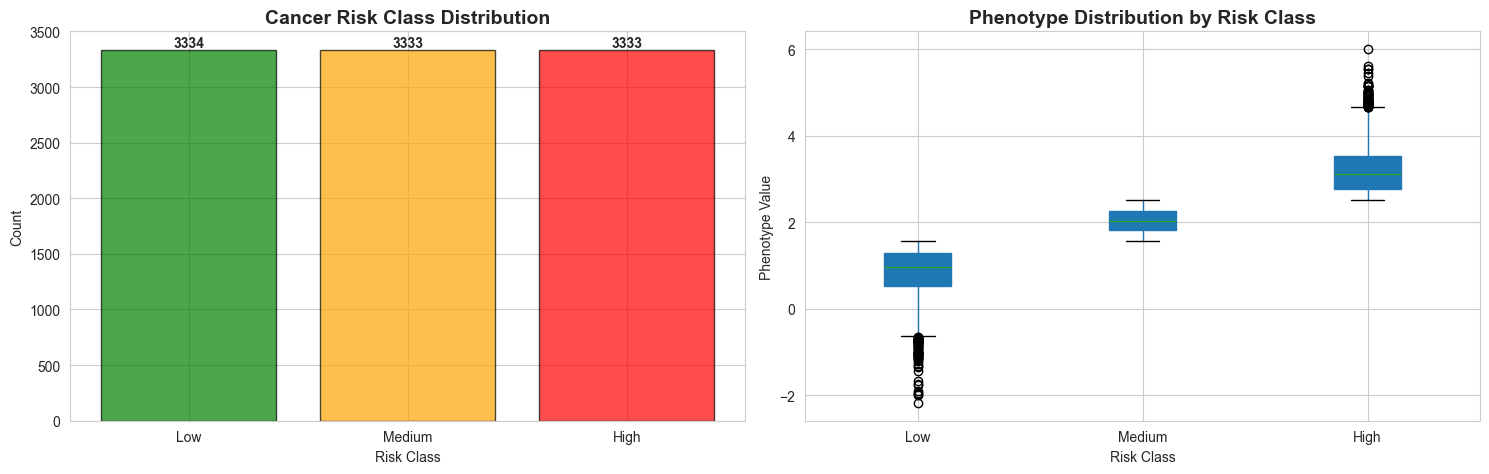

In [16]:
# Create risk classes based on phenotype quantiles
# We'll create risk categories: Low, Medium, High
phenotypes_df['RiskClass'] = pd.qcut(phenotypes_df['Phenotype'], 
                                     q=3, 
                                     labels=['Low', 'Medium', 'High'])

print("Risk Class Distribution:")
print(phenotypes_df['RiskClass'].value_counts())

# Visualize risk classes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Risk class distribution
risk_counts = phenotypes_df['RiskClass'].value_counts()
colors_risk = ['green', 'orange', 'red']
axes[0].bar(risk_counts.index, risk_counts.values, color=colors_risk, edgecolor='black', alpha=0.7)
axes[0].set_title('Cancer Risk Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Class')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(risk_counts.items()):
    axes[0].text(i, val, str(val), ha='center', va='bottom', fontweight='bold')

# Box plot of phenotype by risk class
phenotypes_df.boxplot(column='Phenotype', by='RiskClass', ax=axes[1], patch_artist=True)
axes[1].set_title('Phenotype Distribution by Risk Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Risk Class')
axes[1].set_ylabel('Phenotype Value')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

In [17]:
# Merge and prepare final dataset
merged_df = pd.merge(phenotypes_df, genotypes_df[['ID']], on='ID', how='inner')

# Align X (Genotypes) and y (Risk Class)
y = merged_df['RiskClass']
X = X_genotypes[:len(y)]  # Ensure lengths match

print(f"\nFinal dataset prepared:")
print(f"  Features (X): {X.shape}")
print(f"  Target (y): {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())


Final dataset prepared:
  Features (X): (2024, 45000)
  Target (y): (2024,)

Target distribution:
RiskClass
Low       810
Medium    691
High      523
Name: count, dtype: int64


### 4.1 Dimensionality Reduction (PCA) for Visualization

Applying PCA for visualization...

PCA Results:
  Explained variance ratio (first 10 components): [0.04545801 0.02936989 0.02327641 0.02066396 0.01847036 0.01798187
 0.01609312 0.01535726 0.01267517 0.01248637]
  Cumulative explained variance: [0.04545801 0.0748279  0.09810431 0.11876827 0.13723863 0.15522049
 0.17131362 0.18667088 0.19934605 0.21183241]


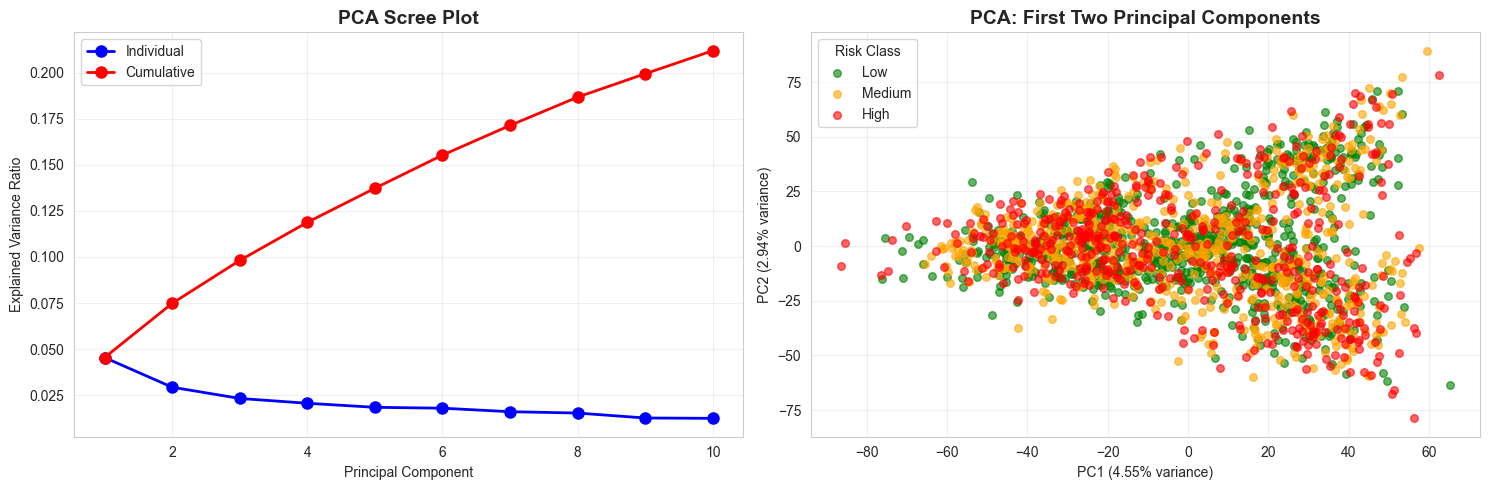

In [18]:
# Apply PCA for visualization
print("Applying PCA for visualization...")
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

print(f"\nPCA Results:")
print(f"  Explained variance ratio (first 10 components): {pca.explained_variance_ratio_}")
print(f"  Cumulative explained variance: {pca.explained_variance_ratio_.cumsum()}")

# Visualize PCA results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].plot(range(1, 11), pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
axes[0].plot(range(1, 11), pca.explained_variance_ratio_.cumsum(), 'ro-', linewidth=2, markersize=8)
axes[0].set_title('PCA Scree Plot', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].legend(['Individual', 'Cumulative'])
axes[0].grid(True, alpha=0.3)

# 2D PCA plot colored by risk class
risk_colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
for risk_class in ['Low', 'Medium', 'High']:
    mask = y == risk_class
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=risk_colors[risk_class], label=risk_class, alpha=0.6, s=30)

axes[1].set_title('PCA: First Two Principal Components', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[1].legend(title='Risk Class')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train-Test Split

In [19]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape}")
print(f"Test Data: {X_test.shape}")

print("\nTraining set class distribution:")
print(y_train.value_counts())

print("\nTest set class distribution:")
print(y_test.value_counts())

Training Data: (1619, 45000)
Test Data: (405, 45000)

Training set class distribution:
RiskClass
Low       648
Medium    553
High      418
Name: count, dtype: int64

Test set class distribution:
RiskClass
Low       162
Medium    138
High      105
Name: count, dtype: int64


## 6. Model Training

In [20]:
# Train Decision Tree Classifier
print("Training Decision Tree Classifier...")
clf = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=10, min_samples_leaf=5)
clf.fit(X_train, y_train)
print("✓ Model trained successfully!")

# Model parameters
print("\nModel Parameters:")
print(f"  Max depth: {clf.max_depth}")
print(f"  Min samples split: {clf.min_samples_split}")
print(f"  Min samples leaf: {clf.min_samples_leaf}")
print(f"  Number of features: {clf.n_features_in_}")
print(f"  Number of classes: {clf.n_classes_}")

Training Decision Tree Classifier...
✓ Model trained successfully!

Model Parameters:
  Max depth: 5
  Min samples split: 10
  Min samples leaf: 5
  Number of features: 45000
  Number of classes: 3


## 7. Model Evaluation

In [21]:
# Make predictions
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nOverfitting check: {abs(train_accuracy - test_accuracy):.4f}")
if abs(train_accuracy - test_accuracy) < 0.05:
    print("✓ Model generalizes well (low overfitting)")
else:
    print("⚠ Potential overfitting detected")

MODEL PERFORMANCE

Training Accuracy: 0.6053 (60.53%)
Test Accuracy: 0.4444 (44.44%)

Overfitting check: 0.1609
⚠ Potential overfitting detected


In [22]:
# Detailed classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred_test))


CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

        High       0.45      0.50      0.47       105
         Low       0.55      0.49      0.52       162
      Medium       0.34      0.36      0.35       138

    accuracy                           0.44       405
   macro avg       0.44      0.45      0.44       405
weighted avg       0.45      0.44      0.45       405



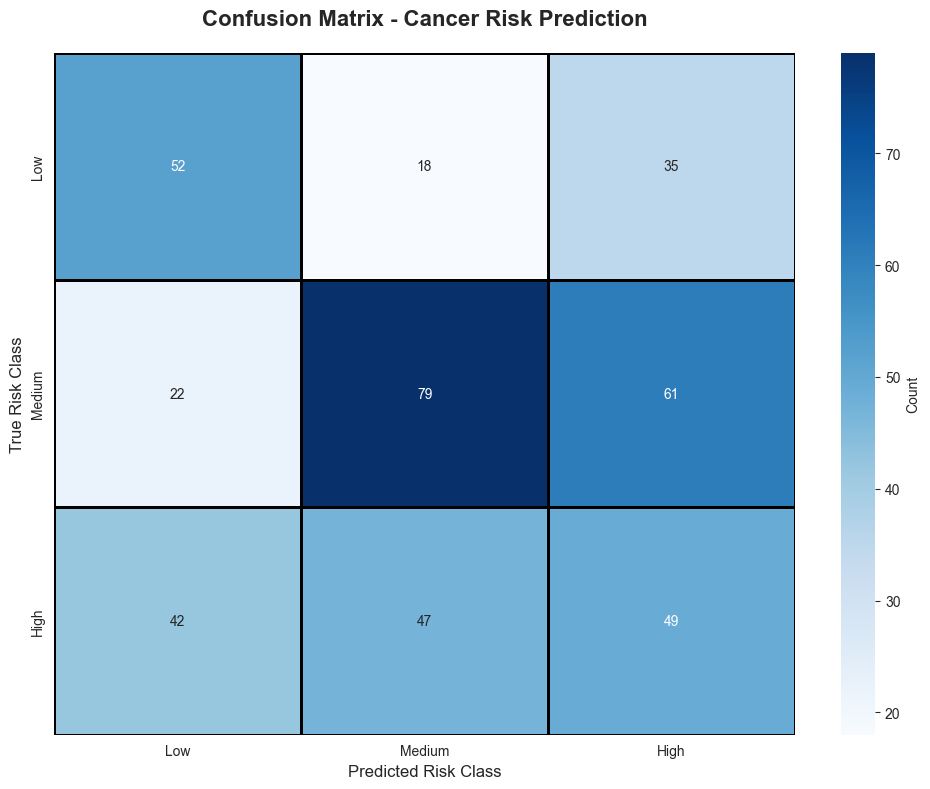


Confusion Matrix Analysis:
  True Negatives (Low correctly predicted): 52
  False Positives (Low predicted as Medium/High): 53
  False Negatives (Medium/High predicted as Low): 64
  True Positives (Medium/High correctly predicted): 236


In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Low', 'Medium', 'High'],
           yticklabels=['Low', 'Medium', 'High'],
           cbar_kws={'label': 'Count'},
           linewidths=1, linecolor='black')
plt.title('Confusion Matrix - Cancer Risk Prediction', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Risk Class', fontsize=12)
plt.xlabel('Predicted Risk Class', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Analysis:")
print(f"  True Negatives (Low correctly predicted): {cm[0, 0]}")
print(f"  False Positives (Low predicted as Medium/High): {cm[0, 1] + cm[0, 2]}")
print(f"  False Negatives (Medium/High predicted as Low): {cm[1, 0] + cm[2, 0]}")
print(f"  True Positives (Medium/High correctly predicted): {cm[1, 1] + cm[1, 2] + cm[2, 1] + cm[2, 2]}")

Performing 5-fold cross-validation...

Cross-Validation Scores: [0.41049383 0.43518519 0.42592593 0.40123457 0.37770898]
Mean CV Accuracy: 0.4101 (+/- 0.0401)


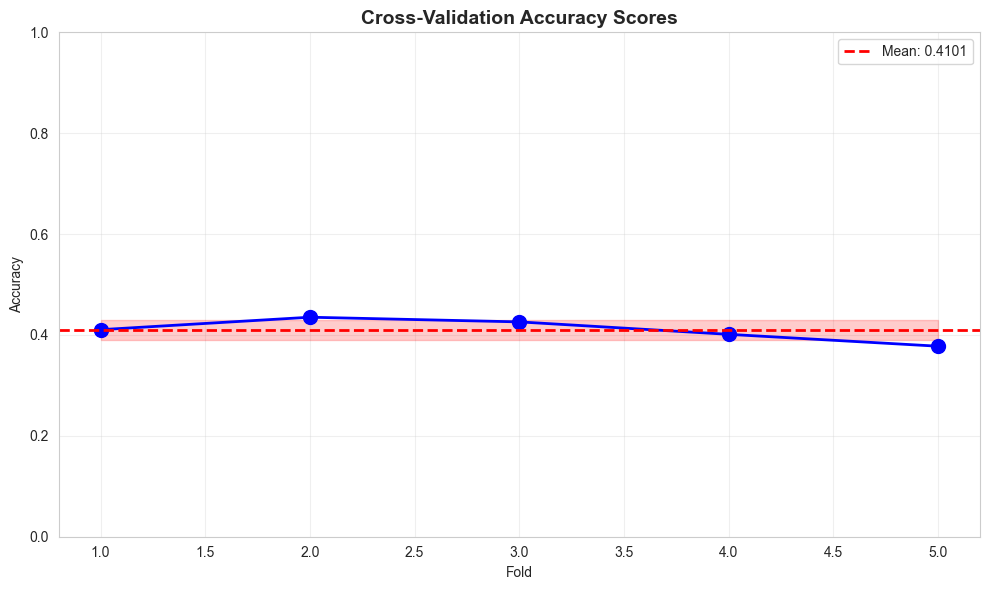

In [24]:
# Cross-validation
print("Performing 5-fold cross-validation...")
cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=10)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), 
                cv_scores.mean() - cv_scores.std(), 
                cv_scores.mean() + cv_scores.std(), 
                alpha=0.2, color='red')
plt.title('Cross-Validation Accuracy Scores', fontsize=14, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Model Interpretability


Top 20 Most Important SNPs:
  1. SNP_2497: 0.213698
  2. SNP_2492: 0.065476
  3. SNP_23916: 0.055123
  4. SNP_2395: 0.044308
  5. SNP_16688: 0.039013
  6. SNP_36506: 0.037341
  7. SNP_29081: 0.036067
  8. SNP_41751: 0.034296
  9. SNP_3375: 0.032927
  10. SNP_1643: 0.032770
  11. SNP_10891: 0.032387
  12. SNP_44420: 0.031586
  13. SNP_25248: 0.030199
  14. SNP_44661: 0.030189
  15. SNP_19580: 0.029656
  16. SNP_41078: 0.029388
  17. SNP_17075: 0.028954
  18. SNP_31075: 0.027937
  19. SNP_36378: 0.026879
  20. SNP_21867: 0.023211


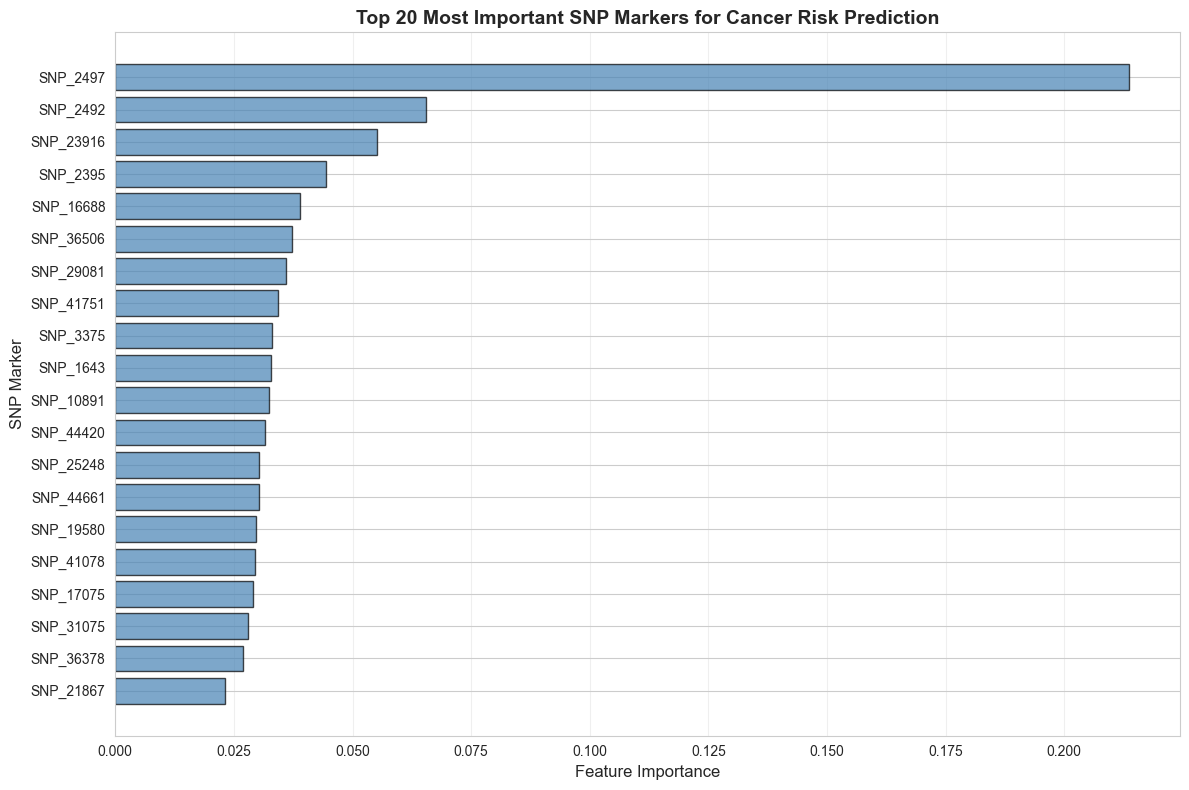

In [25]:
# Feature importance
feature_importance = clf.feature_importances_
top_n = 20
top_indices = np.argsort(feature_importance)[-top_n:][::-1]

print(f"\nTop {top_n} Most Important SNPs:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i}. SNP_{idx}: {feature_importance[idx]:.6f}")

# Visualize feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(top_n), feature_importance[top_indices], color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(top_n), [f'SNP_{idx}' for idx in top_indices])
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('SNP Marker', fontsize=12)
plt.title(f'Top {top_n} Most Important SNP Markers for Cancer Risk Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [26]:
# Extract decision tree rules
tree_rules = export_text(clf, feature_names=[f"SNP_{i}" for i in range(X.shape[1])], max_depth=3)
print("\n" + "=" * 60)
print("DECISION TREE RULES (First 3 levels)")
print("=" * 60)
print(tree_rules)


DECISION TREE RULES (First 3 levels)
|--- SNP_2497 <= 0.50
|   |--- SNP_2492 <= 0.50
|   |   |--- SNP_16688 <= 0.50
|   |   |   |--- SNP_29081 <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- SNP_29081 >  1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- SNP_16688 >  0.50
|   |   |   |--- SNP_36378 <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- SNP_36378 >  1.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- SNP_2492 >  0.50
|   |   |--- SNP_25248 <= 1.50
|   |   |   |--- SNP_44661 <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- SNP_44661 >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- SNP_25248 >  1.50
|   |   |   |--- SNP_21867 <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- SNP_21867 >  1.50
|   |   |   |   |--- class: High
|--- SNP_2497 >  0.50
|   |--- SNP_2395 <= 1.50
|   |   |--- SNP_23916 <= 1.50
|   |   |   |--- SNP_1643 <= 

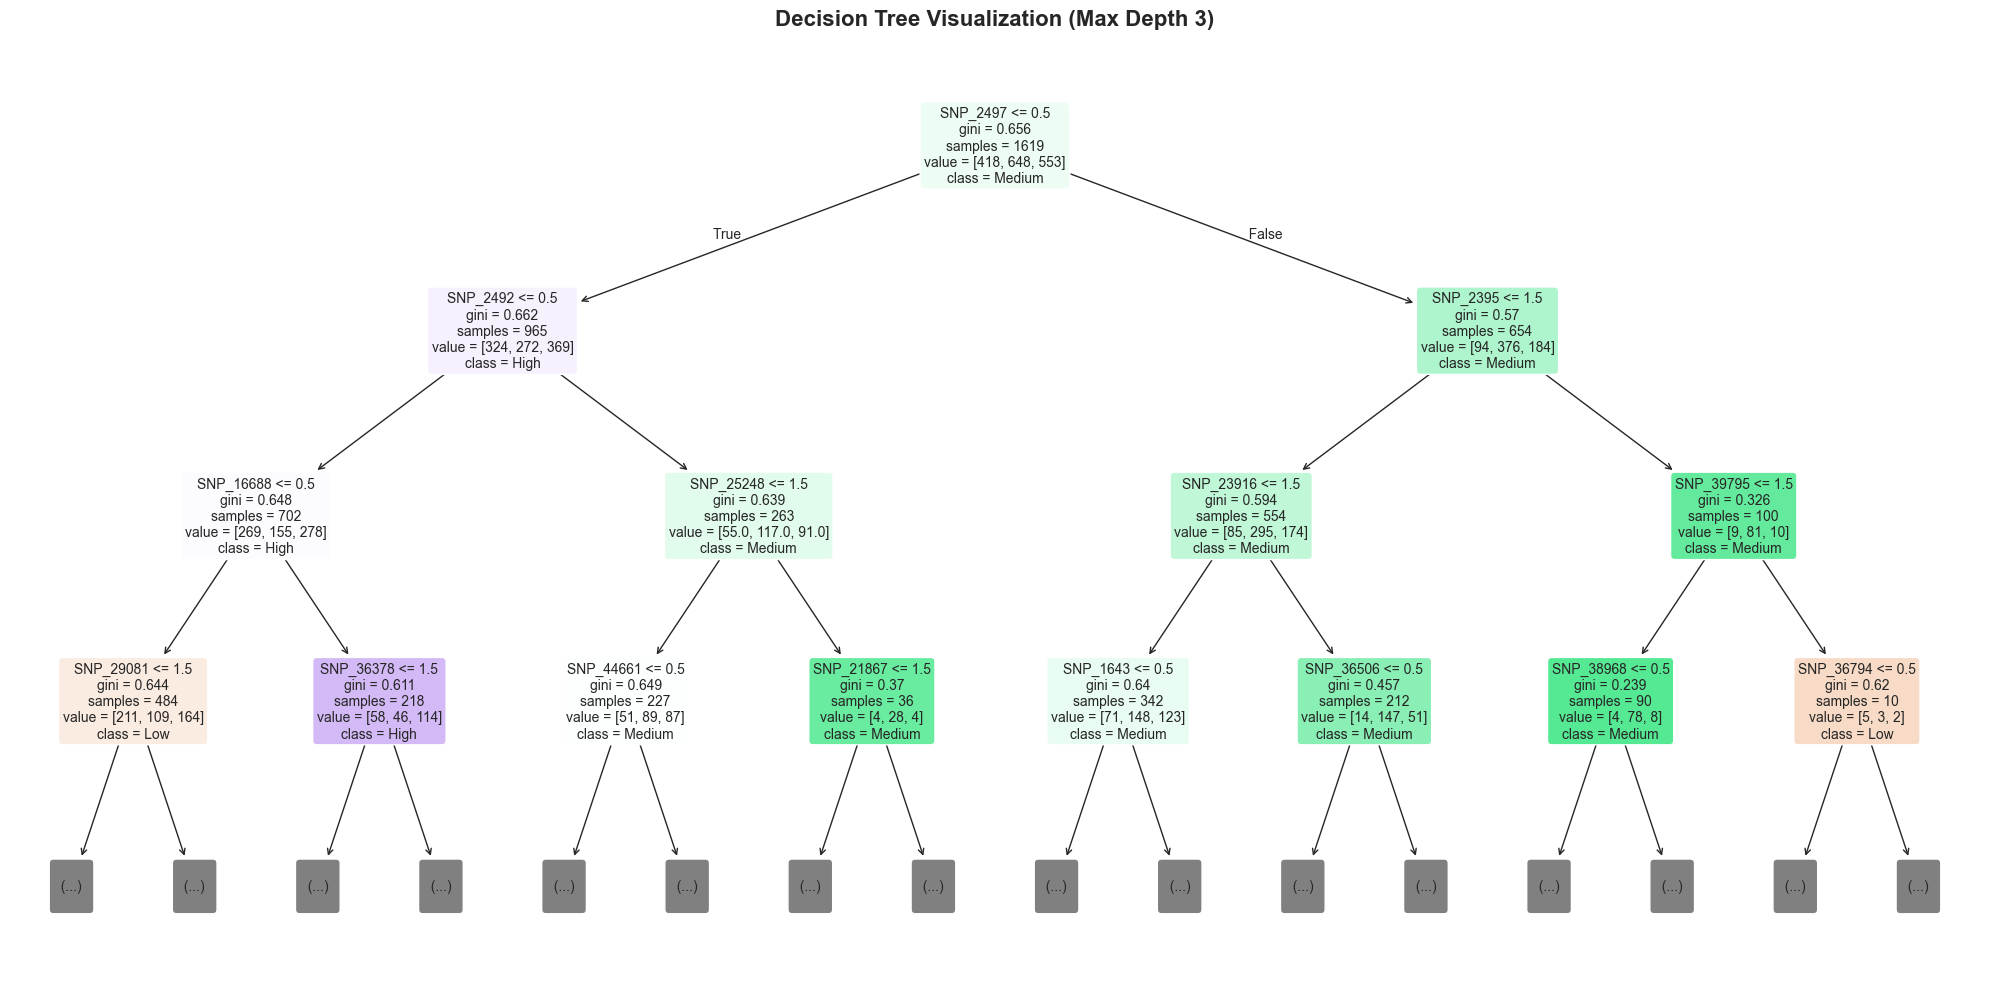

✓ Decision tree visualization complete


In [27]:
# Visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf, 
         feature_names=[f"SNP_{i}" for i in range(X.shape[1])],
         class_names=['Low', 'Medium', 'High'],
         filled=True, 
         rounded=True,
         fontsize=10,
         max_depth=3)
plt.title('Decision Tree Visualization (Max Depth 3)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Decision tree visualization complete")

## 9. Save Model

In [31]:
# Save the trained model
joblib.dump(clf, MODEL_EXPORT_PATH)
print(f"✓ Model saved to {MODEL_EXPORT_PATH}")

# Save feature importance
feature_importance_df = pd.DataFrame({
    'SNP_Index': range(len(feature_importance)),
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

feature_importance_df.to_csv('feature_importance.csv', index=False)
print("✓ Feature importance saved to feature_importance.csv")

# Save model metrics
metrics = {
    'train_accuracy': train_accuracy,
    'test_accuracy': test_accuracy,
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std()
}

with open('model_metrics.txt', 'w') as f:
    f.write("Cancer Risk Prediction Model Metrics\n")
    f.write("=" * 50 + "\n")
    for key, value in metrics.items():
        f.write(f"{key}: {value:.4f}\n")

print("✓ Model metrics saved to model_metrics.txt")
print("\n" + "=" * 60)
print("MODEL TRAINING AND EVALUATION COMPLETE!")
print("=" * 60)

✓ Model saved to cancer_risk_model.joblib
✓ Feature importance saved to feature_importance.csv
✓ Model metrics saved to model_metrics.txt

MODEL TRAINING AND EVALUATION COMPLETE!
